<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled186.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ammonia Synthesis**

This is the reaction
$
N_2 + 3H_2 \rightleftharpoons 2NH_3.
$

Direct problem:

We consider the initial values $z(0) =0$, $x_1^0 = 5$, $x_2^0=6$ and $y_1(0) = 0.2$.  The parameter values used are  $k_1= 0.10$ and $k_2 = 0.15$.

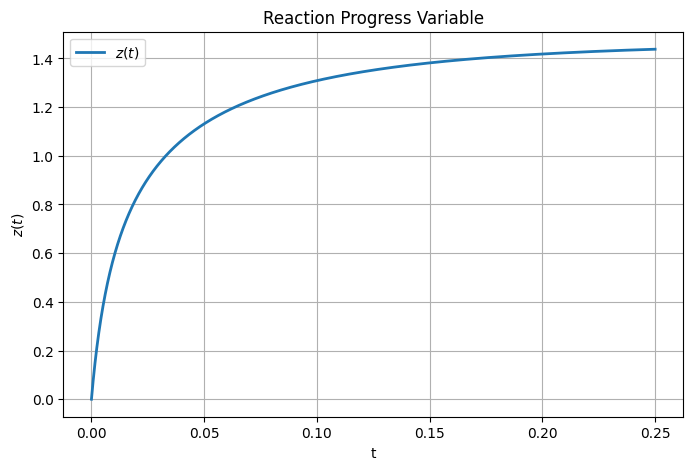

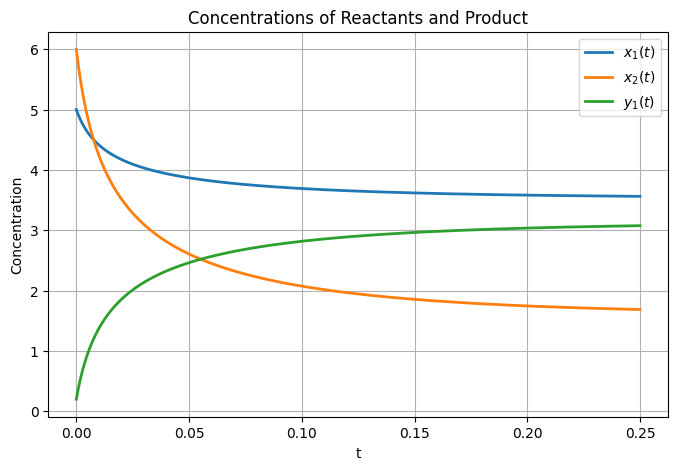

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

k1 = 0.1
k2 = 0.15

x1_0 = 5
x2_0 = 6
y1_0 = 0.2

# ============================================================
# ODE
#
# z'(t) =
# k1 (x1_0-z)(x2_0-3z)^3
# - k2 (y1_0+2z)^2
# ============================================================

def f(t, z):

    forward = (
        k1
        * (x1_0 - z)
        * (x2_0 - 3*z)**3
    )

    backward = (
        k2
        * (y1_0 + 2*z)**2
    )

    return forward - backward

# ============================================================
# Runge--Kutta 4th order method
# ============================================================

# Time interval
T = 0.250

# Number of steps
N = 4000

# Step size
h = T / N

# Arrays
t = np.linspace(0, T, N+1)

z = np.zeros(N+1)

# Initial condition
z[0] = 0.0

# RK4 loop
for n in range(N):

    k_1 = f(t[n], z[n])

    k_2 = f(
        t[n] + h/2,
        z[n] + h*k_1/2
    )

    k_3 = f(
        t[n] + h/2,
        z[n] + h*k_2/2
    )

    k_4 = f(
        t[n] + h,
        z[n] + h*k_3
    )

    z[n+1] = (
        z[n]
        + (h/6)*(k_1 + 2*k_2 + 2*k_3 + k_4)
    )

# ============================================================
# Concentrations
# ============================================================

x1 = x1_0 - z
x2 = x2_0 - 3*z
y1 = y1_0 + 2*z

# ============================================================
# Plot z(t)
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t,
    z,
    linewidth=2,
    label=r'$z(t)$'
)

plt.xlabel("t")

plt.ylabel(r"$z(t)$")

plt.title(
    "Reaction Progress Variable"
)

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# Plot concentrations
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t,
    x1,
    linewidth=2,
    label=r'$x_1(t)$'
)

plt.plot(
    t,
    x2,
    linewidth=2,
    label=r'$x_2(t)$'
)

plt.plot(
    t,
    y1,
    linewidth=2,
    label=r'$y_1(t)$'
)

plt.xlabel("t")

plt.ylabel("Concentration")

plt.title(
    "Concentrations of Reactants and Product"
)

plt.grid(True)

plt.legend()

plt.show()

Epoch     0 | Loss = 5.7618e+02 | k1 = 0.2000 | k2 = 0.2000 | a1 = 1.0000 | a2 = 2.0000 | b1 = 1.0000
Epoch   500 | Loss = 2.5318e+00 | k1 = 0.1796 | k2 = 0.2547 | a1 = 0.9029 | a2 = 1.8094 | b1 = 1.2105
Epoch  1000 | Loss = 8.2010e-01 | k1 = 0.1731 | k2 = 0.2743 | a1 = 0.8731 | a2 = 1.7494 | b1 = 1.2731
Epoch  1500 | Loss = 4.0785e-01 | k1 = 0.1689 | k2 = 0.2721 | a1 = 0.8543 | a2 = 1.7101 | b1 = 1.2252
Epoch  2000 | Loss = 2.4383e-01 | k1 = 0.1659 | k2 = 0.2690 | a1 = 0.8408 | a2 = 1.6814 | b1 = 1.1918
Epoch  2500 | Loss = 1.6895e-01 | k1 = 0.1638 | k2 = 0.2654 | a1 = 0.8311 | a2 = 1.6602 | b1 = 1.1716
Epoch  3000 | Loss = 1.3264e-01 | k1 = 0.1623 | k2 = 0.2612 | a1 = 0.8243 | a2 = 1.6449 | b1 = 1.1628
Epoch  3500 | Loss = 1.1436e-01 | k1 = 0.1615 | k2 = 0.2564 | a1 = 0.8202 | a2 = 1.6346 | b1 = 1.1650
Epoch  4000 | Loss = 1.0457e-01 | k1 = 0.1613 | k2 = 0.2508 | a1 = 0.8185 | a2 = 1.6289 | b1 = 1.1787
Epoch  4500 | Loss = 9.8623e-02 | k1 = 0.1616 | k2 = 0.2442 | a1 = 0.8190 | a2 = 1

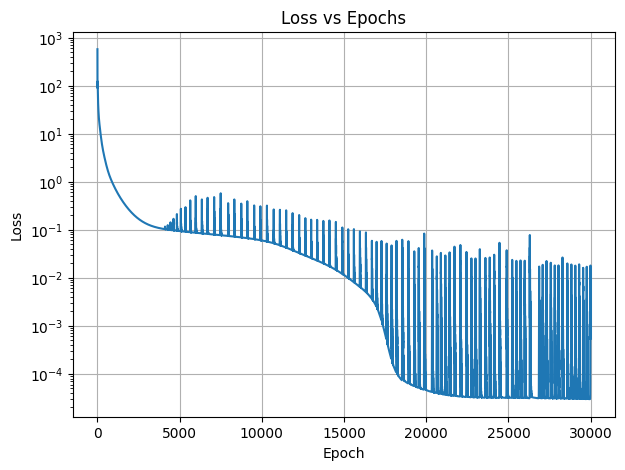

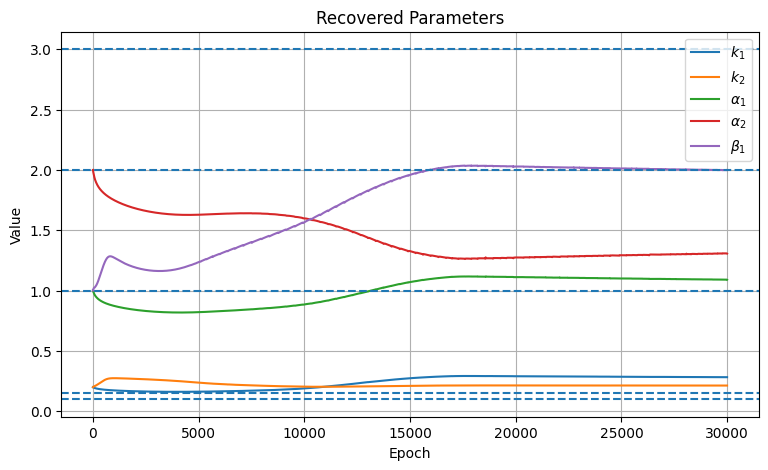

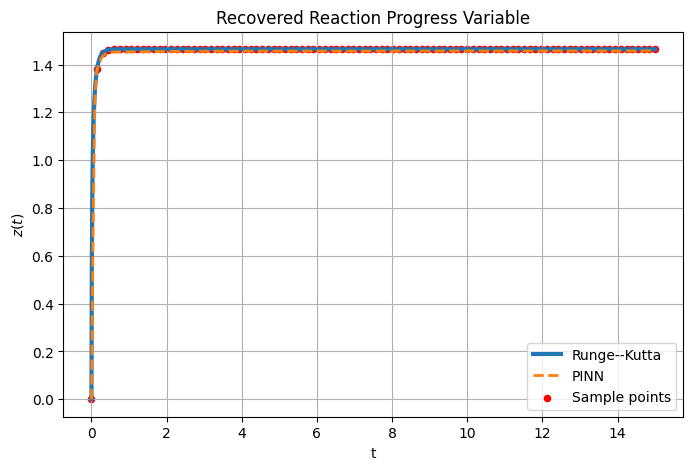


Recovered Parameters
True k1       = 0.1
Recovered k1  = 0.282560

True k2       = 0.15
Recovered k2  = 0.213297

True alpha1   = 1.0
Recovered alpha1 = 1.090360

True alpha2   = 3.0
Recovered alpha2 = 1.306944

True beta1    = 2.0
Recovered beta1 = 1.997936


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.backend.set_floatx('float32')

# ============================================================
# TRUE PARAMETERS
# ============================================================

k1_true = 0.10
k2_true = 0.15

alpha1_true = 1.0   # exponent for N2
alpha2_true = 3.0   # exponent for H2
beta1_true  = 2.0   # exponent for NH3

# Initial concentrations


x1_0 = 5
x2_0 = 6
y1_0 = 0.2

# ============================================================
# ODE
#
# z' =
# k1 (x1-z)^alpha1 (x2-3z)^alpha2
# - k2 (y1+2z)^beta1
# ============================================================

def f(t, z):

    forward = (
        k1_true
        * (x1_0 - z)**alpha1_true
        * (x2_0 - 3*z)**alpha2_true
    )

    backward = (
        k2_true
        * (y1_0 + 2*z)**beta1_true
    )

    return forward - backward

# ============================================================
# RUNGE--KUTTA SOLUTION
# ============================================================

T = 15.0

N_rk = 5000

h = T / N_rk

t_rk = np.linspace(0, T, N_rk + 1)

z_rk = np.zeros(N_rk + 1)

z_rk[0] = 0.0

for n in range(N_rk):

    k_1 = f(t_rk[n], z_rk[n])

    k_2 = f(
        t_rk[n] + h/2,
        z_rk[n] + h*k_1/2
    )

    k_3 = f(
        t_rk[n] + h/2,
        z_rk[n] + h*k_2/2
    )

    k_4 = f(
        t_rk[n] + h,
        z_rk[n] + h*k_3
    )

    z_rk[n+1] = (
        z_rk[n]
        + (h/6)*(k_1 + 2*k_2 + 2*k_3 + k_4)
    )

# ============================================================
# NH3 concentration
# y1(t) = y1_0 + 2 z(t)
# ============================================================

y1_rk = y1_0 + 2*z_rk

# ============================================================
# SAMPLE N=100 DATA POINTS
# ============================================================

N_data = 100

idx = np.linspace(
    0,
    N_rk,
    N_data,
    dtype=int
)

t_data = t_rk[idx].reshape(-1,1)

y1_data_clean = y1_rk[idx].reshape(-1,1)

# ============================================================
# ADD SMALL NOISE
# ============================================================

noise_level = 0.00

np.random.seed(1234)

noise = (
    noise_level
    * np.random.randn(*y1_data_clean.shape)
)

y1_data = y1_data_clean + noise

# ============================================================
# BUILD THE PINN
# ============================================================

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(1,)),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(1)

])

# ============================================================
# TRAINABLE PARAMETERS
# Positive parametrization
# ============================================================

k1_var = tf.Variable(
    np.log(0.20),
    dtype=tf.float32
)

k2_var = tf.Variable(
    np.log(0.20),
    dtype=tf.float32
)

a1_var = tf.Variable(
    np.log(1.0),
    dtype=tf.float32
)

a2_var = tf.Variable(
    np.log(2.0),
    dtype=tf.float32
)

b1_var = tf.Variable(
    np.log(1.0),
    dtype=tf.float32
)

# ============================================================
# HARD EMBEDDING
# z(0)=0
# ============================================================

def z_theta(t):

    return (
        t/(1+t)
        * model(t)
    )

# ============================================================
# COLLOCATION POINTS
# ============================================================

N_col = 300

t_col = np.linspace(
    0,
    T,
    N_col
).reshape(-1,1).astype(np.float32)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

epochs = 30000

# ============================================================
# STORAGE
# ============================================================

loss_history = []

k1_history = []
k2_history = []

a1_history = []
a2_history = []
b1_history = []

# ============================================================
# TRAINING
# ============================================================

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        # ----------------------------------------
        # Positive parameters
        # ----------------------------------------

        k1 = tf.exp(k1_var)
        k2 = tf.exp(k2_var)

        alpha1 = tf.exp(a1_var)
        alpha2 = tf.exp(a2_var)

        beta1 = tf.exp(b1_var)

        # ----------------------------------------
        # DATA LOSS
        # ----------------------------------------

        t_d = tf.convert_to_tensor(
            t_data,
            dtype=tf.float32
        )

        y_d = tf.convert_to_tensor(
            y1_data,
            dtype=tf.float32
        )

        z_pred_data = z_theta(t_d)

        y_pred_data = y1_0 + 2*z_pred_data

        loss_data = tf.reduce_mean(
            (y_pred_data - y_d)**2
        )

        # ----------------------------------------
        # PHYSICS LOSS
        # ----------------------------------------

        t_f = tf.convert_to_tensor(t_col)

        with tf.GradientTape() as tape2:

            tape2.watch(t_f)

            z_pred = z_theta(t_f)

        dzdt = tape2.gradient(
            z_pred,
            t_f
        )

        term1 = tf.abs(
            x1_0 - z_pred
        ) + 1e-6

        term2 = tf.abs(
            x2_0 - 3*z_pred
        ) + 1e-6

        term3 = tf.abs(
            y1_0 + 2*z_pred
        ) + 1e-6

        rhs = (
            k1
            * tf.pow(term1, alpha1)
            * tf.pow(term2, alpha2)
            -
            k2
            * tf.pow(term3, beta1)
        )

        residual = dzdt - rhs

        loss_phys = tf.reduce_mean(
            residual**2
        )

        # ----------------------------------------
        # TOTAL LOSS
        # ----------------------------------------

        loss = (
            10.0*loss_data
            + loss_phys
        )

    # ----------------------------------------
    # TRAINABLE VARIABLES
    # ----------------------------------------

    variables = (
        model.trainable_variables
        +
        [
            k1_var,
            k2_var,
            a1_var,
            a2_var,
            b1_var
        ]
    )

    grads = tape.gradient(
        loss,
        variables
    )

    optimizer.apply_gradients(
        zip(grads, variables)
    )

    # ----------------------------------------
    # STORE HISTORY
    # ----------------------------------------

    loss_history.append(
        loss.numpy()
    )

    k1_history.append(
        k1.numpy()
    )

    k2_history.append(
        k2.numpy()
    )

    a1_history.append(
        alpha1.numpy()
    )

    a2_history.append(
        alpha2.numpy()
    )

    b1_history.append(
        beta1.numpy()
    )

    # ----------------------------------------
    # PRINT
    # ----------------------------------------

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.4e} | "
            f"k1 = {k1.numpy():.4f} | "
            f"k2 = {k2.numpy():.4f} | "
            f"a1 = {alpha1.numpy():.4f} | "
            f"a2 = {alpha2.numpy():.4f} | "
            f"b1 = {beta1.numpy():.4f}"
        )

# ============================================================
# PREDICTIONS
# ============================================================

t_test = t_rk.reshape(-1,1).astype(np.float32)

z_nn = z_theta(
    tf.convert_to_tensor(t_test)
).numpy().flatten()

# ============================================================
# PLOT LOSS
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.grid(True)

plt.show()

# ============================================================
# PLOT PARAMETERS
# ============================================================

plt.figure(figsize=(9,5))

plt.plot(
    k1_history,
    label=r'$k_1$'
)

plt.plot(
    k2_history,
    label=r'$k_2$'
)

plt.plot(
    a1_history,
    label=r'$\alpha_1$'
)

plt.plot(
    a2_history,
    label=r'$\alpha_2$'
)

plt.plot(
    b1_history,
    label=r'$\beta_1$'
)

plt.axhline(
    k1_true,
    linestyle='--'
)

plt.axhline(
    k2_true,
    linestyle='--'
)

plt.axhline(
    alpha1_true,
    linestyle='--'
)

plt.axhline(
    alpha2_true,
    linestyle='--'
)

plt.axhline(
    beta1_true,
    linestyle='--'
)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.title("Recovered Parameters")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PLOT z(t)
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_rk,
    z_rk,
    linewidth=3,
    label='Runge--Kutta'
)

plt.plot(
    t_rk,
    z_nn,
    '--',
    linewidth=2,
    label='PINN'
)

plt.scatter(
    t_data,
    (y1_data - y1_0)/2,
    color='red',
    s=20,
    label='Sample points'
)

plt.xlabel("t")

plt.ylabel(r"$z(t)$")

plt.title(
    "Recovered Reaction Progress Variable"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FINAL PARAMETERS
# ============================================================

print("\n============================")
print("Recovered Parameters")
print("============================")

print(f"True k1       = {k1_true}")
print(f"Recovered k1  = {k1.numpy():.6f}")

print()

print(f"True k2       = {k2_true}")
print(f"Recovered k2  = {k2.numpy():.6f}")

print()

print(f"True alpha1   = {alpha1_true}")
print(f"Recovered alpha1 = {alpha1.numpy():.6f}")

print()

print(f"True alpha2   = {alpha2_true}")
print(f"Recovered alpha2 = {alpha2.numpy():.6f}")

print()

print(f"True beta1    = {beta1_true}")
print(f"Recovered beta1 = {beta1.numpy():.6f}")